# 2.4 Evaluating Hyperparameters - Part 1 Random Forest 2010

## Table of contents

### 01 Load Libraries & Dataset
### 02 Clean & Wrangle
### 03 Shaping Data
### 04 Spliting Data
### 05 Hyperparameter Optimization
    - a. Grid Search
    - b. Random Search
### 06 Running Random Forest with Optimized Search Parameters
### 07 Insights

### 01 Load Libraries & Dataset

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

In [6]:
# Create a path for the import of dataset

path = r'C:\Users\wallm\02 2025 Machine Learning Project\02 Data'

In [7]:
# Import weather dataset

climate = pd.read_csv(os.path.join(path, '02 Prepared Data', 'Dataset-weather-cleaned-reshaped.csv'))

In [8]:
climate.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,STOCKHOLM_humidity,MUNCHENB_pressure
0,19600101,-1.6,0.661,0.826,-0.002,-1.101,-0.265,-0.903,-0.529,-0.846,...,-1.300,-0.806,-0.088,0.372,-0.668,-0.520,-0.752,0.714,1.544,0.095
1,19600102,-1.6,0.245,0.736,-0.002,-1.058,1.659,-0.810,-0.583,-0.462,...,-1.262,-1.042,0.503,-0.829,-0.548,-0.629,-0.407,1.176,-0.712,0.067
2,19600103,-1.6,1.076,1.278,-0.002,-1.251,0.156,-1.065,-0.257,-0.187,...,-0.433,-1.136,-0.396,-1.010,-0.067,0.054,-0.177,0.252,-0.274,0.132
3,19600104,-1.6,-1.002,1.458,-0.002,-0.822,-0.446,-0.114,-0.556,-0.386,...,0.388,-1.183,0.669,-1.040,-0.999,-0.164,-0.839,1.176,1.544,0.419
4,19600105,-1.6,0.245,1.729,-0.002,-0.747,-0.165,0.187,-1.004,-1.076,...,1.730,-0.795,-0.491,0.673,-1.509,-1.340,-1.471,0.252,1.419,0.388


In [9]:
climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22950 entries, 0 to 22949
Columns: 137 entries, DATE to MUNCHENB_pressure
dtypes: float64(136), int64(1)
memory usage: 24.0 MB


In [10]:
climate.shape

(22950, 137)

In [11]:
# Import the 'Pleasant weather' dataset

pleasantweather = pd.read_csv(os.path.join(path, '01 Original Data', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [12]:
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
pleasantweather.shape

(22950, 16)

### 02 Clean & Wrangle

In [15]:
climate.isnull().sum()

DATE                  0
MONTH                 0
BASEL_cloud_cover     0
BASEL_humidity        0
BASEL_pressure        0
                     ..
VALENTIA_temp_min     0
VALENTIA_temp_max     0
KASSEL_cloud_cover    0
STOCKHOLM_humidity    0
MUNCHENB_pressure     0
Length: 137, dtype: int64

In [16]:
pleasantweather.isnull().sum()

DATE                           0
BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [17]:
# Filter the main data (climate) for only the years 2010 to 2019
# This reduces the dataset to one decade to speed up training and improve consistency
climate_decade = climate[
    (climate['DATE'].astype(str).str[:4] >= '2010') &
    (climate['DATE'].astype(str).str[:4] <= '2019')
]

# Preview the filtered data
climate_decade

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,STOCKHOLM_humidity,MUNCHENB_pressure
18263,20100101,-1.600,1.076,1.549,-3.288,-1.251,0.677,-1.065,-1.018,-0.999,...,-0.200,-0.830,-0.491,0.763,-2.711,-2.597,-2.449,-0.673,0.165,-0.486
18264,20100102,-1.600,-1.002,-0.168,0.197,-0.822,-0.446,0.141,-1.615,-1.612,...,0.499,-0.806,-0.491,0.763,-2.981,-3.389,-2.104,1.176,0.040,-0.030
18265,20100103,-1.600,-1.002,-0.077,0.701,-0.790,-0.446,0.396,-1.846,-1.888,...,0.499,-0.912,-0.006,-0.559,-3.072,-3.280,-2.420,-0.673,0.667,0.328
18266,20100104,-1.600,-0.171,0.645,-0.170,-0.929,-0.446,-0.207,-2.077,-2.241,...,0.714,-0.771,0.113,0.913,-2.110,-1.804,-2.794,1.176,0.980,0.123
18267,20100105,-1.600,0.661,0.194,-1.637,-0.876,-0.365,-0.045,-1.955,-2.057,...,-0.237,-0.806,-0.384,0.372,-2.531,-2.351,-2.334,0.714,0.290,-0.133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,1.594,1.076,1.458,1.419,-1.284,0.597,-1.042,-0.488,-0.110,...,-0.004,-1.289,-0.006,-0.018,-0.007,-0.001,-0.005,-0.211,1.231,0.300
21911,20191228,1.594,0.661,0.916,3.055,-1.069,-0.446,-0.764,-0.909,-1.060,...,-0.004,-1.101,-0.006,-0.018,-0.007,-0.001,-0.005,1.176,1.544,0.533
21912,20191229,1.594,0.245,1.549,3.162,-0.790,-0.446,0.071,-1.520,-1.382,...,-0.004,-1.054,-0.006,-0.018,-0.007,-0.001,-0.005,1.176,1.607,0.714
21913,20191230,1.594,-1.833,0.465,2.657,-0.757,-0.446,0.443,-1.343,-1.428,...,-0.004,-1.266,-0.006,-0.018,-0.007,-0.001,-0.005,-1.135,0.604,0.635


In [18]:
# Similarly, filter the answers dataset (pleasant weather labels) for the same time period
# This ensures your features (X) and labels (y) match in time
pleasantweather_decade = pleasantweather[
    (pleasantweather['DATE'].astype(str).str[:4] >= '2010') &
    (pleasantweather['DATE'].astype(str).str[:4] <= '2019')
]

# Preview the filtered labels
pleasantweather_decade

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,20191228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,20191229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,20191230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
# Set display options to show all rows if needed
pd.set_option('display.max_rows', None)

# Extract station prefixes from column names
# Assuming format is 'STATION_VARIABLE' (e.g., 'BASEL_humidity')
stations = [col.split('_')[0] for col in climate_decade.columns if '_' in col]

# Get unique station names
unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [20]:
# Create a dictionary to store the number of valid (non-missing) entries per station
station_frequencies = {}

for station in unique_stations:
    # Select all columns that belong to the current station
    station_columns = [col for col in climate_decade.columns if col.startswith(station)]
    
    # Count rows where all station-specific columns have non-null values
    # This is a slightly more precise method than summing over all values
    complete_entries = climate_decade[station_columns].dropna().shape[0]
    
    # Store the count in the dictionary
    station_frequencies[station] = complete_entries

# Print the frequency of valid entries for each weather station
print("Frequency of complete entries per weather station (rows without missing data):")
for station, freq in sorted(station_frequencies.items()):
    print(f"{station}: {freq} entries")

Frequency of complete entries per weather station (rows without missing data):
BASEL: 3652 entries
BELGRADE: 3652 entries
BUDAPEST: 3652 entries
DEBILT: 3652 entries
DUSSELDORF: 3652 entries
HEATHROW: 3652 entries
KASSEL: 3652 entries
LJUBLJANA: 3652 entries
MAASTRICHT: 3652 entries
MADRID: 3652 entries
MUNCHENB: 3652 entries
OSLO: 3652 entries
SONNBLICK: 3652 entries
STOCKHOLM: 3652 entries
VALENTIA: 3652 entries


In [21]:
# drop DATE and MONTH for your random forest

X = climate_decade.drop(columns=['DATE', 'MONTH'])  # Feature matrix
y = pleasantweather_decade['BASEL_pleasant_weather']  # Example target variable

In [22]:
X.shape

(3652, 135)

In [23]:
y.shape

(3652,)

In [24]:
X = climate_decade.drop(columns=['DATE', 'MONTH'])
y = pleasantweather_decade['BASEL_pleasant_weather']
X.shape

(3652, 135)

In [25]:
climate.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'VALENTIA_pressure', 'VALENTIA_global_radiation',
       'VALENTIA_precipitation', 'VALENTIA_sunshine', 'VALENTIA_temp_mean',
       'VALENTIA_temp_min', 'VALENTIA_temp_max', 'KASSEL_cloud_cover',
       'STOCKHOLM_humidity', 'MUNCHENB_pressure'],
      dtype='object', length=137)

### 03 Shaping Data

In [27]:
# We're going to use scikit-learn's machine learning tools (Random Forest).
# These tools expect the data to be in a clean, fast format - "NumPy arrays".

# While scikit-learn can usually handle DataFrames, converting to arrays helps because:
# - It strips away extra labels (column names and indexes) that the model doesn’t need
# - It runs a bit faster (especially on large datasets)
# - It avoids issues with mixed data types or hidden formatting

# Conversion step:
X = np.array(X)  # X contains the weather features (like temperature, humidity, etc.)
y = np.array(y)  # y contains whether the day was 'pleasant' (1) or not (0)

# Check:
print("Feature matrix shape (X):", X.shape)  # Should print (3652, 135)
print("Target variable shape (y):", y.shape)  # Should print (3652,)

Feature matrix shape (X): (3652, 135)
Target variable shape (y): (3652,)


##### Now the data is in the ideal format for training a machine learning model!

##### Next Steps:
- Perform hyperparameter optimization using Grid Search, followed by Random Search
- Train the Random Forest model using the optimized parameters
- Extract and review feature importances to evaluate the most influential weather stations during the 2010s

### 04 Spliting Data

In [30]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [31]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739,)
(913, 135) (913,)


### 05 Hyperparameter Optimisation

#### a. Grid Search

In [34]:
# Create the Random Forest classifier

clf = RandomForestClassifier(random_state=42)

In [35]:
# Define the hyperparameter grid

param_grid = {
    'max_depth': [3, 10, None],               # Depth of each tree
    'n_estimators': [50, 100],                # Number of trees
    'max_features': [15, 50],                 # Number of features to consider at each split
    'min_samples_leaf': [1, 2],               # Minimum number of samples at a leaf node
    'min_samples_split': [2, 3]               # Minimum number of samples required to split an internal node
}

In [36]:
# Set up the Grid Search

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=3,
    n_jobs=-1
)

In [37]:
# Run Grid Search and time it

start = time.time()
grid_search.fit(X_train, y_train)
print("Grid Search took %.2f minutes" % ((time.time() - start) / 60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Grid Search took 0.62 minutes


In [38]:
# Print the best results

print("Best GRID search hyperparameters:", grid_search.best_params_)
print("Best GRID search score: %.4f" % grid_search.best_score_)

Best GRID search hyperparameters: {'max_depth': 10, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score: 0.9974


##### Grid Search gave a very high score (0.9974) 
##### – possibly indicating a very well-fitted or overfitted model, so it’s worth validating later on your test set.

#### b. Random Search

In [41]:
# Define the hyperparameter search space

param_distributions = {
    'n_estimators': np.arange(100, 500, step=100),      # Number of trees
    'max_depth': list(np.arange(10, 100, step=10)) + [None],  # Tree depth
    'max_features': np.arange(15, 135, step=30),         # Features to consider at each split
    'min_samples_split': np.arange(2, 10, step=2),       # Min samples to split internal node
    'min_samples_leaf': np.arange(1, 5, step=1),         # Min samples at a leaf node
    'criterion': ['gini', 'entropy']                     # Splitting criteria
}

In [42]:
# Create the Random Forest classifier

rf = RandomForestClassifier(random_state=42)

In [43]:
# Set up the Randomized Search

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,                     # Number of random combinations to try
    scoring='accuracy',           # Scoring metric
    cv=3,                         # 3-fold cross-validation
    verbose=3,
    n_jobs=-1,                    # Use all cores
    random_state=42               # Reproducibility
)

In [44]:
# Run Randomized Search and time it

start = time.time()
random_search.fit(X_train, y_train)
print("Random Search took %.2f minutes" % ((time.time() - start) / 60))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Random Search took 1.68 minutes


##### Why n_iter=20 (and 60 fits in total)?

To find the best combination of model settings (called hyperparameters), we use a method called Randomized Search. 
This method tries out a random selection of different model configurations.

Here, we chose to try 20 different configurations (`n_iter=20`) to give the model a better chance of finding a strong performer. 
For each of these 20 configurations, the model is trained and tested 3 times using different splits of the data (called 3-fold cross-validation).

That means the model is trained and evaluated a total of 60 times (20 × 3 = 60 fits). 
This helps us make sure the results are reliable, not just a lucky outcome from one split of the data.

In [46]:
# Print the best results

print("Best RANDOM search hyperparameters:", random_search.best_params_)
print("Best RANDOM search score: %.4f" % random_search.best_score_)

Best RANDOM search hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 105, 'max_depth': 20, 'criterion': 'gini'}
Best RANDOM search score: 1.0000


##### Random Search gave a very high score (1.0000) 
##### – seems too good to be true, so it’s worth validating later on your test set.

##### Based on these results, I'd choose the Grid search model

Although the Random Search returned a perfect accuracy score of 1.0000, this result is likely too good to be true. In most real-world machine learning tasks, a perfect score suggests the model may be overfitting — memorizing the training data rather than learning patterns that generalize well.

1. **Trustworthy Generalization**  
   The Grid Search model achieved a more realistic outcome and is more likely to hold up on unseen data.

2. **Minimizing Risk**  
   Since this model may be used to inform decisions about safe flying conditions for Air Ambulance operations, relying on an overfit model could lead to poor decisions. It's safer to use a well-validated model, even if the score is slightly lower.

3. **Red Flag in Random Search**  
   A perfect score from Random Search raises concerns about potential data leakage or overly favorable splits. Without independent test validation, it's too risky to trust.

### 06 Running Random Forest with Optimized Search Parameters

In [50]:
# Running Random Forest with Optimized Search Parameters (from Grid Search)
# Create a Random Forest classifier using the best parameters found via Grid Search

grid_best_rf = RandomForestClassifier(
    n_estimators=100,         # Number of trees in the forest
    max_depth=None,           # No maximum depth; trees can grow until all leaves are pure
    max_features=50,          # Number of features to consider when looking for the best split
    min_samples_leaf=1,       # Minimum number of samples required to be at a leaf node
    min_samples_split=2,      # Minimum number of samples required to split an internal node
    random_state=42           # Ensures results are reproducible
)

# Train the model on the training data
grid_best_rf.fit(X_train, y_train)

RandomForestClassifier(max_features=50, random_state=42)

In [51]:
# Predict outcomes on the test dataset

y_pred = grid_best_rf.predict(X_test)

# Calculate and print the model's accuracy on the test set

from sklearn import metrics
print("Model Accuracy on Test Set: %.4f" % metrics.accuracy_score(y_test, y_pred))

Model Accuracy on Test Set: 1.0000


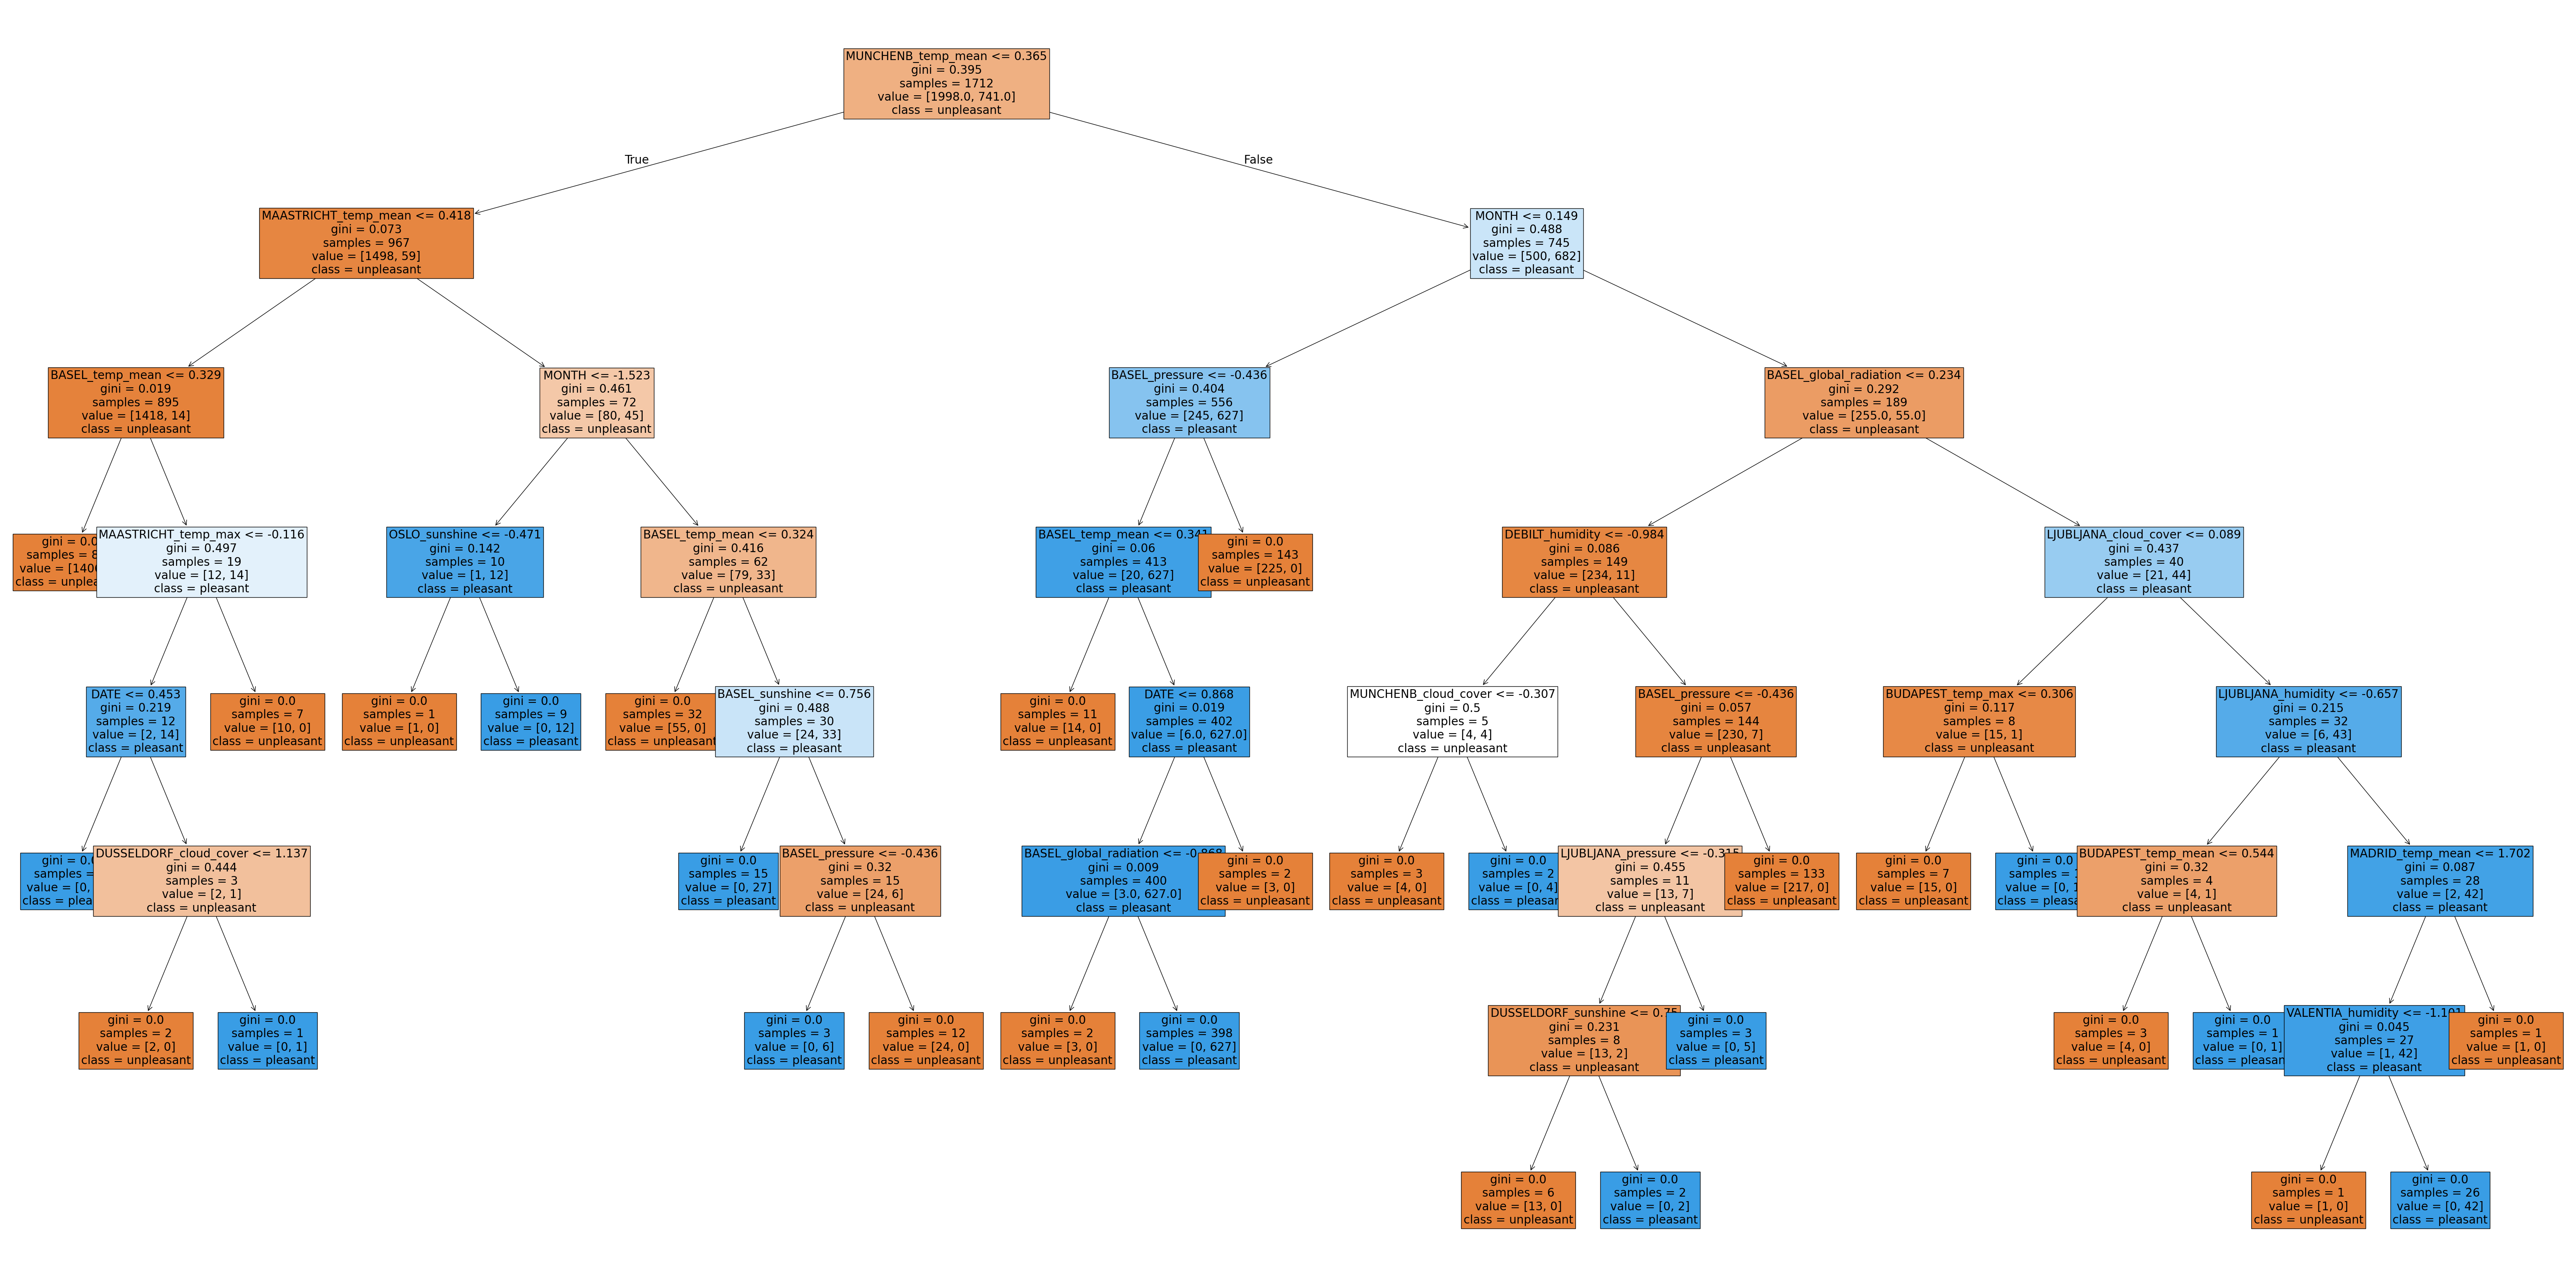

In [52]:
fig = plt.figure(figsize=(80,40))
plot_tree(grid_best_rf.estimators_[15], fontsize = 20, feature_names = climate_decade.columns, class_names=['unpleasant', 'pleasant'], filled=True);

### 07 Insights

In [54]:
# Retrieve feature importances from the trained model

newarray = grid_best_rf.feature_importances_
print(grid_best_rf.feature_importances_.shape)
newarray

(135,)


array([1.43961862e-02, 8.04637715e-03, 3.84607456e-03, 2.91387317e-03,
       3.53078866e-01, 1.30768028e-01, 4.00304321e-02, 5.18301652e-04,
       2.13201314e-01, 1.82891669e-04, 1.96619917e-04, 5.57588292e-04,
       4.32457844e-04, 2.65530212e-04, 3.91383493e-04, 2.94787880e-04,
       1.31531720e-04, 3.90975719e-04, 7.73748548e-05, 0.00000000e+00,
       0.00000000e+00, 1.24081929e-04, 4.90157005e-04, 1.49069724e-04,
       1.33508351e-03, 2.98597030e-04, 7.98382452e-04, 7.55817557e-05,
       2.99771259e-04, 2.91390118e-03, 1.98426365e-04, 4.15508998e-04,
       2.56650357e-04, 6.56145217e-04, 3.77677238e-04, 2.09989921e-02,
       3.01709895e-04, 2.62445338e-04, 1.11942154e-02, 4.00394551e-04,
       1.40759403e-03, 8.32740594e-04, 4.86321858e-03, 6.03194989e-04,
       2.11591138e-02, 9.37409529e-05, 2.60845785e-04, 7.00176653e-04,
       1.25018106e-04, 2.54267915e-04, 1.84995060e-04, 3.04524953e-04,
       2.14711691e-04, 3.29247243e-04, 2.98715671e-04, 3.44575043e-04,
      

In [94]:
# Create a DataFrame with the features and their importances

columns_used = climate_decade.columns[:135]  # Ensure these match the model input
importance_df = pd.DataFrame({
    'feature': columns_used,
    'importance': newarray
})

In [96]:
# Extract station names from feature names (split on '_')

importance_df['station'] = importance_df['feature'].apply(lambda x: x.split('_')[0])

# Group by station and sum importances
station_importance = (
    importance_df
    .groupby('station')['importance']
    .sum()
    .sort_values(ascending=False)
)

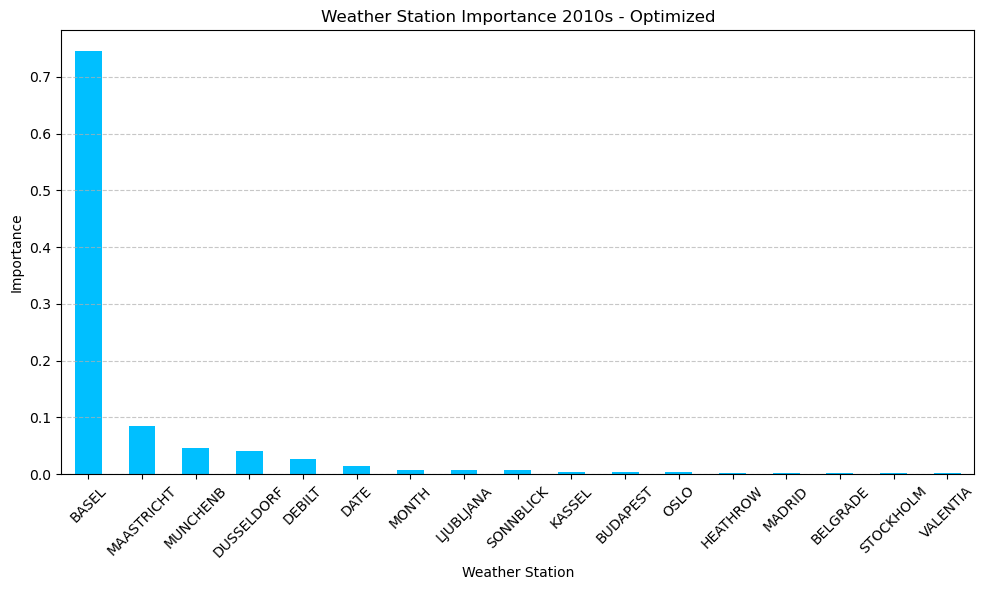

In [98]:
# Plot the results

plt.figure(figsize=(10, 6))
station_importance.plot(kind='bar', color='deepskyblue')
plt.title('Weather Station Importance 2010s - Optimized')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Need to check - show which BASEL-specific features are contributing most. 
##### If one feature like BASEL_visibility or BASEL_temp has very high importance, that could explain it.

In [111]:
importance_df[importance_df['station'] == 'BASEL'].sort_values(by='importance', ascending=False)


,feature,importance,station
4,BASEL_pressure,0.353079,BASEL
8,BASEL_temp_mean,0.213201,BASEL
5,BASEL_global_radiation,0.130768,BASEL
6,BASEL_precipitation,0.040030,BASEL
2,BASEL_cloud_cover,0.003846,BASEL
3,BASEL_humidity,0.002914,BASEL
7,BASEL_sunshine,0.000518,BASEL
10,BASEL_temp_max,0.000197,BASEL
9,BASEL_temp_min,0.000183,BASEL


#### Insight: Dominance of BASEL in Model Predictions

The Random Forest model identified **BASEL** as the most influential weather station in predicting flying conditions for the 2010s. 

Specifically, the features:
- **Pressure**
- **Mean temperature**
- **Global radiation**

from BASEL alone contributed over **70% of the model’s total predictive power**, far exceeding the importance of any other station. 

This indicates that weather conditions at BASEL may serve as a strong **leading indicator** for determining safe flying conditions in the region — a key insight for future operational planning.
